# 04. Final Coloring Book Pipeline

이 노트북은 01, 02, 03번 노트북에서 검증한 단계를 하나로 연결합니다.

입력:

- `data/flowers.jpg` 입력 이미지
- 원하는 색상 개수 K
- 경계선 Canny 임계값
- 선 두께
- 최소 영역 크기

출력:

1. 원본 이미지
2. K-Means, Posterization, Median Cut 색상 단순화 비교
3. 색상 오차와 실제 고유색 수 비교
4. Sobel, Laplacian, Canny, Hybrid Color Boundary 경계선 비교
5. Connected Components 영역 분리 결과
6. 색상 번호가 들어간 최종 컬러링북 이미지
7. RGB 색상표와 색상 인덱스 표
8. K 변화에 따른 복잡도 비교

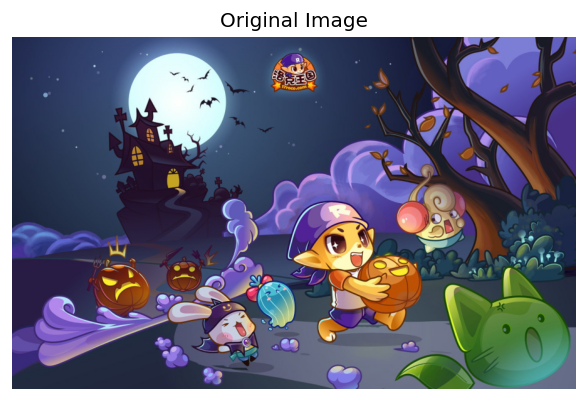

In [1]:
# Kernel -> Restart & Run All 로 처음부터 실행하세요.
import os
import sys
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np

# 공통 함수가 들어 있는 src 폴더를 import 경로에 추가합니다.
sys.path.append("src")
import importlib
import coloringbook_utils as coloringbook_utils
importlib.reload(coloringbook_utils)
from coloringbook_utils import *

# 결과 저장 폴더와 샘플 입력 폴더를 생성합니다.
ensure_dirs()
OUTPUT_DIR = "ychoutput"
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120

# 지정한 입력 이미지를 사용해 전체 파이프라인을 실행합니다.
IMAGE_PATH = "data/ych.jpg"
if not IMAGE_PATH or not os.path.exists(IMAGE_PATH):
    print(f"WARNING: '{IMAGE_PATH}' not found, using built-in sample image instead.")
    IMAGE_PATH = None

try:
    image = load_image(IMAGE_PATH)
except FileNotFoundError as exc:
    print(f"WARNING: {exc}; using built-in sample image instead.")
    image = load_image(None)

show_images([("Original Image", image)], cols=1, figsize=(5, 5))

## 전체 파라미터

실험 발표에서는 `K=5, 10, 20`을 비교하고, 최종 결과는 보통 `K=10`부터 조정하는 방식이 좋습니다.

In [2]:
# 최종 결과의 기본 색상 수입니다. 보고서에서는 K=5, 10, 20, 50 비교도 함께 사용합니다.
K = 20
K_VALUES = [5, 10, 20, 50]

# Canny 임계값입니다. 값이 높으면 노이즈는 줄지만 필요한 경계가 사라질 수 있습니다.
CANNY_LOW = 80
CANNY_HIGH = 180

# 최종 Hybrid edge는 K-Means 라벨 전체 경계가 아니라 Lab 색 차이가 큰 경계만 추가합니다.
# 값이 커질수록 그림자/그라데이션으로 생긴 세세한 edge가 줄어듭니다.
COLOR_EDGE_DELTA = 35
FINAL_CLOSE_ITER = 4

# 최종 컬러링북 선 두께입니다. 가장 얇은 선을 사용합니다.
LINE_THICKNESS = 1

# 02번 노트북의 경계 비교용 Hybrid 선 두께입니다.
EDGE_COMPARE_THICKNESS = 1

# 너무 작은 영역은 번호가 읽기 어렵기 때문에 제거합니다.
MIN_REGION_AREA = 160

# 그림자, 질감, 그라데이션으로 인한 색 깨짐을 줄이기 위한 입력 평탄화 설정입니다.
# Bilateral filter는 주요 경계는 유지하면서 영역 내부의 작은 색 변화만 완화합니다.
SIMPLIFY_DIAMETER = 9
SIMPLIFY_SIGMA_COLOR = 90
SIMPLIFY_SIGMA_SPACE = 90

## 최종 파이프라인 실행

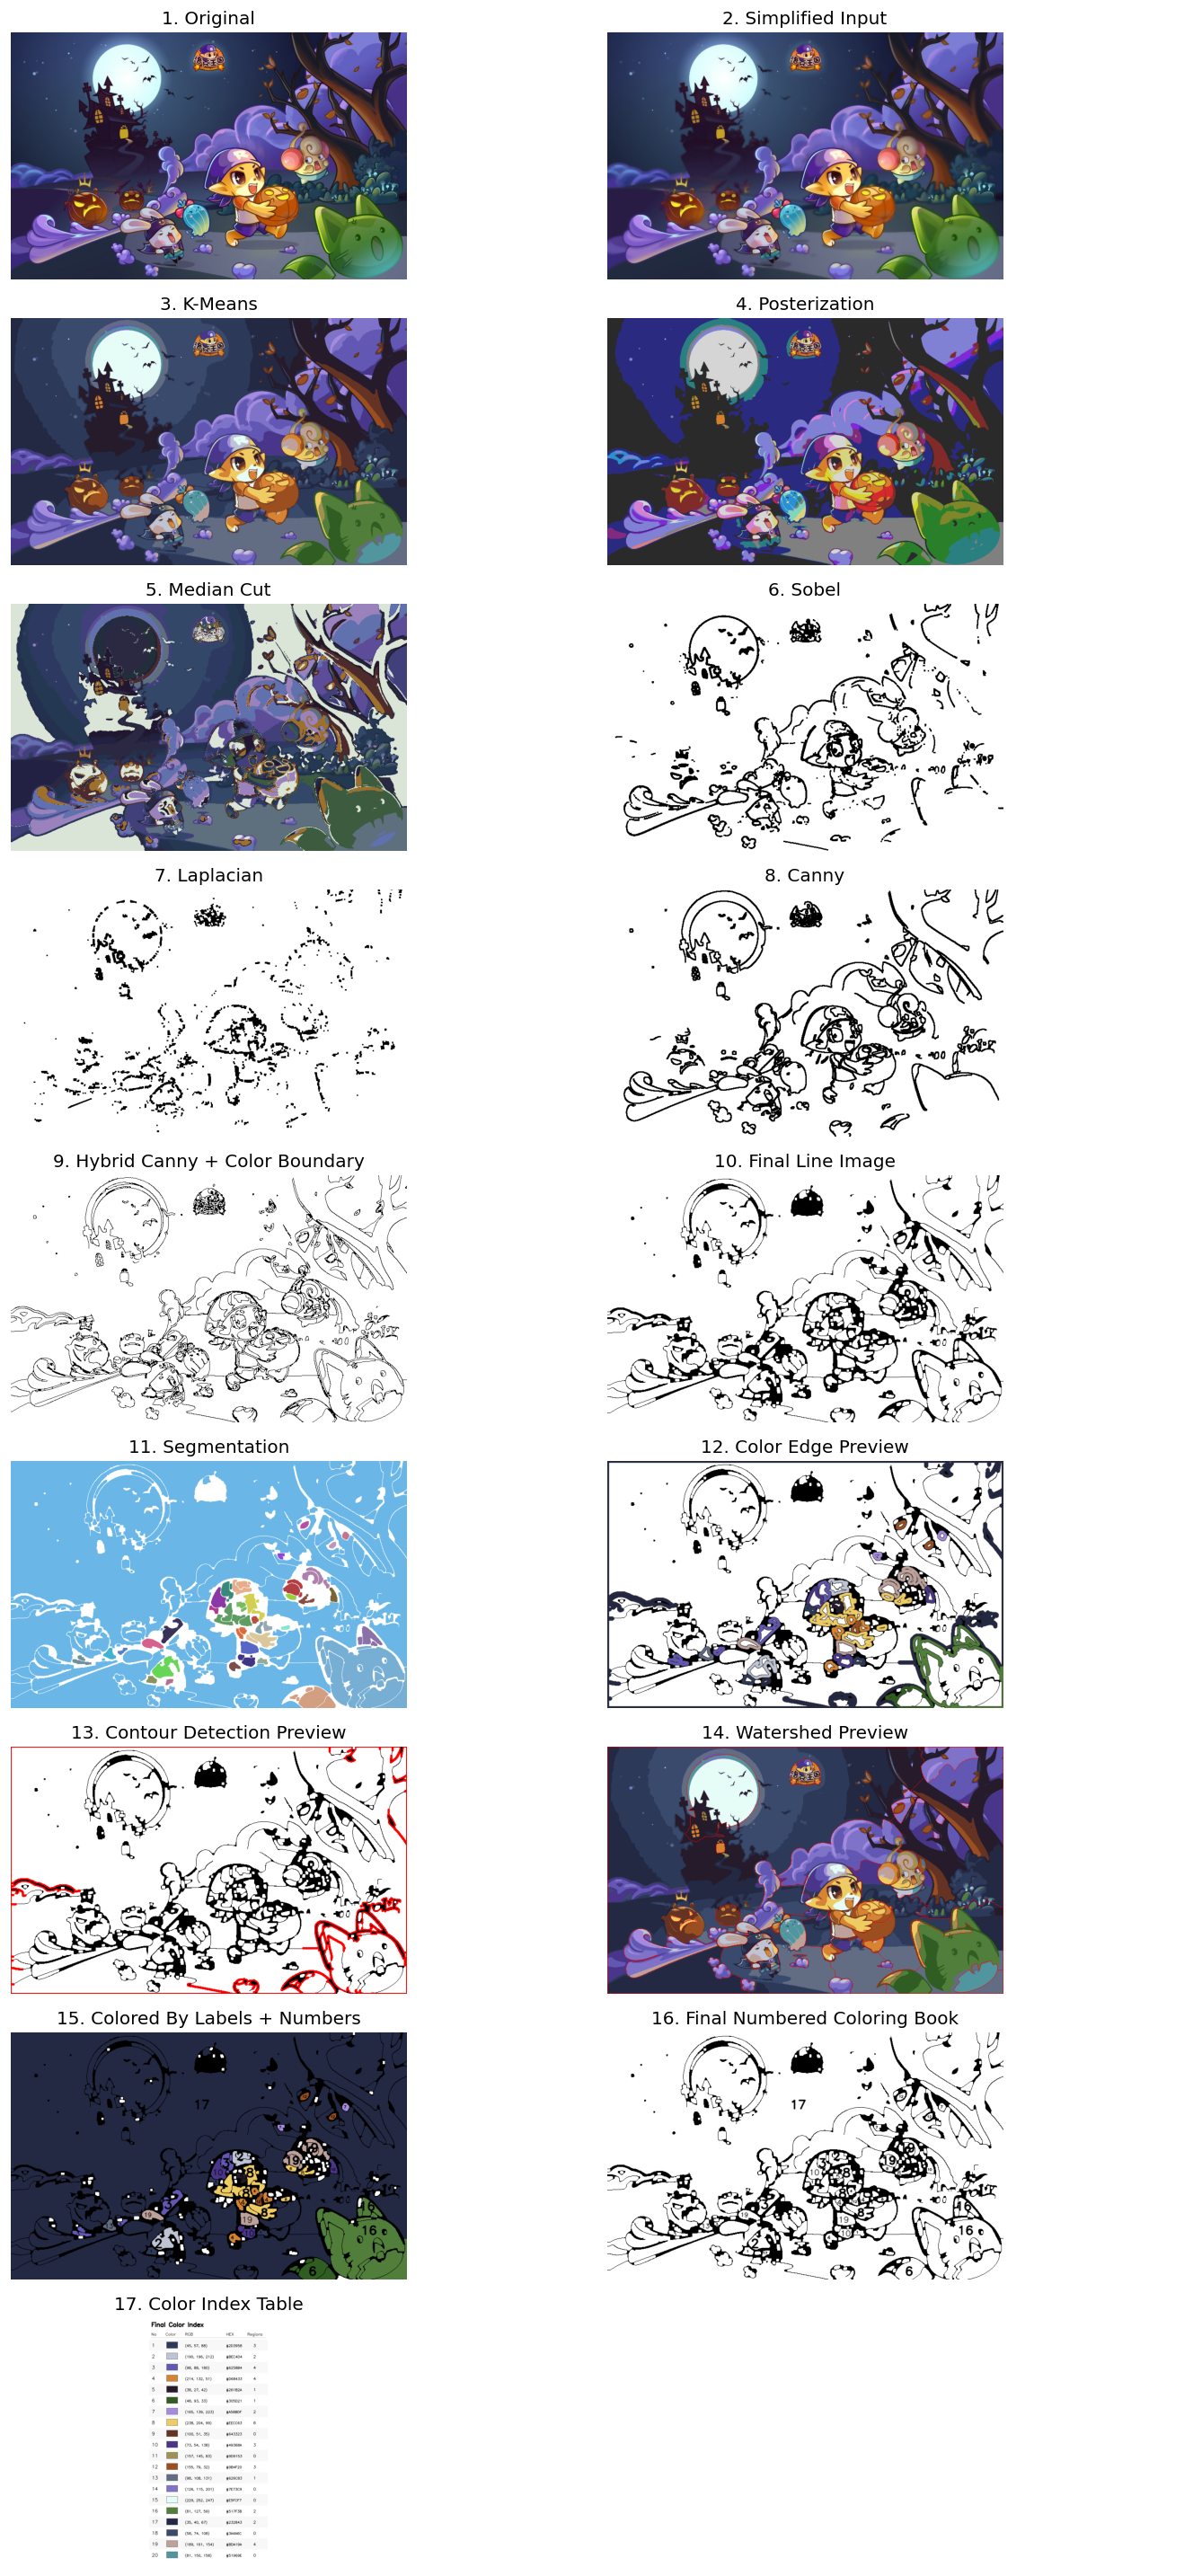

In [3]:
# 0. 입력 평탄화: 그림자, 질감, 그라데이션을 완화해 색상 군집이 깨지는 것을 줄입니다.
(simplified_image, simplify_time) = timed_call(
    cv2.bilateralFilter,
    image,
    SIMPLIFY_DIAMETER,
    SIMPLIFY_SIGMA_COLOR,
    SIMPLIFY_SIGMA_SPACE,
)

# 1. 색상 단순화: 평탄화된 이미지를 기준으로 01번 노트북의 세 알고리즘을 비교합니다.
(kmeans_img, kmeans_palette, kmeans_labels), kmeans_time = timed_call(kmeans_quantization_with_labels, simplified_image, K)
(poster_img, poster_palette), poster_time = timed_call(posterization, simplified_image, K)
(median_img, median_palette), median_time = timed_call(median_cut_quantization, simplified_image, K)

quality_rows = []
for name, result, runtime in [
    ("K-Means", kmeans_img, kmeans_time),
    ("Posterization", poster_img, poster_time),
    ("Median Cut", median_img, median_time),
]:
    quality_rows.append({
        "algorithm": name,
        "runtime_sec": runtime,
        "color_error": quantization_error(simplified_image, result),
        "unique_colors": count_unique_colors(result),
    })

# 2. 경계선 추출: 02번 노트북과 같은 Sobel, Laplacian, Canny, Hybrid 비교를 수행합니다.
(sobel_raw, sobel_time) = timed_call(sobel_edges, kmeans_img, 65)
(lap_raw, lap_time) = timed_call(laplacian_edges, kmeans_img, 25)
(canny_raw, canny_time) = timed_call(canny_edges, kmeans_img, CANNY_LOW, CANNY_HIGH)

# Label map 경계는 그림자/그라데이션 조각까지 모두 선으로 만들 수 있어 최종 결과에서는 쓰지 않습니다.
# 대신 Lab 색 차이가 충분히 큰 경계만 Canny에 보강합니다.
hybrid_start = time.perf_counter()
color_raw = color_boundary_edges(kmeans_img, min_delta=COLOR_EDGE_DELTA)
canny_covered = cv2.dilate(canny_raw, np.ones((3, 3), np.uint8), iterations=1)
color_new = cv2.bitwise_and(color_raw, cv2.bitwise_not(canny_covered))
hybrid_raw = cv2.bitwise_or(canny_raw, color_new)
hybrid_time = time.perf_counter() - hybrid_start

sobel_clean = clean_edges(sobel_raw, open_iter=1, close_iter=1, thickness=1)
lap_clean = clean_edges(lap_raw, open_iter=1, close_iter=1, thickness=1)
canny_clean = clean_edges(canny_raw, open_iter=0, close_iter=1, thickness=2)
hybrid_compare_clean = clean_edges(hybrid_raw, open_iter=0, close_iter=1, thickness=EDGE_COMPARE_THICKNESS)
hybrid_final_clean = clean_edges(hybrid_raw, open_iter=0, close_iter=FINAL_CLOSE_ITER, thickness=LINE_THICKNESS)

sobel_line = coloring_line_image(sobel_clean)
lap_line = coloring_line_image(lap_clean)
canny_line = coloring_line_image(canny_clean)
hybrid_compare_line = coloring_line_image(hybrid_compare_clean)
final_line_image = coloring_line_image(hybrid_final_clean)

edge_rows = [
    {"algorithm": "Sobel", "runtime_sec": sobel_time, "edge_density": edge_density(sobel_clean), "hci_note": "두꺼운 변화 감지, 질감 노이즈 주의"},
    {"algorithm": "Laplacian", "runtime_sec": lap_time, "edge_density": edge_density(lap_clean), "hci_note": "세부 변화 민감, 작은 노이즈 많음"},
    {"algorithm": "Canny", "runtime_sec": canny_time, "edge_density": edge_density(canny_clean), "hci_note": "선명도와 노이즈 균형 우수"},
    {"algorithm": "Hybrid Color Boundary", "runtime_sec": hybrid_time, "edge_density": edge_density(hybrid_compare_clean), "hci_note": "비슷한 밝기의 색상 경계까지 분리"},
]

# 3. 영역 분리 및 번호화: 03번 노트북과 같은 Connected Components 기반 흐름을 사용합니다.
(region_map, regions), seg_time = timed_call(segment_connected_components, final_line_image, MIN_REGION_AREA)
background_color = estimate_background_color(kmeans_img)
regions = assign_region_color_numbers(
    regions,
    region_map,
    kmeans_labels,
    kmeans_palette,
    background_color=background_color,
    background_color_threshold=16,
    merge_background_similar=True,
)
numbered_regions = colorable_regions(regions)
region_preview = color_region_preview(region_map)
color_edge_preview = color_region_edge_preview(final_line_image, region_map, regions, kmeans_palette, thickness=4)

# 각 영역을 dominant 팔레트 색으로 채운 미리보기입니다.
colored_by_labels = np.full_like(simplified_image, 255)
for region in regions:
    color = region.get("color_rgb")
    if color is None:
        continue
    colored_by_labels[region_map == region["id"]] = np.array(color, dtype=np.uint8)
colored_by_labels[final_line_image < 128] = 0

numbered_coloringbook = label_regions(final_line_image, regions, font_scale=0.9, region_map=region_map)
colored_by_labels_numbered = label_regions(colored_by_labels, regions, font_scale=0.9, region_map=region_map)
color_index = save_color_index_table(kmeans_palette, f"{OUTPUT_DIR}/04_color_index_table.png", regions, "Final Color Index")
numbered_with_index = combine_with_color_index(
    numbered_coloringbook,
    kmeans_palette,
    regions,
    f"{OUTPUT_DIR}/04_numbered_with_color_index.png",
    "Final Color Index",
)

# Contour와 Watershed는 03번과 같은 비교용 결과로 함께 저장합니다.
contour_preview, contours = contour_regions(final_line_image, MIN_REGION_AREA)
watershed_preview, watershed_markers = watershed_segmentation(kmeans_img)

# 4. 저장: 단계별 결과를 출력 폴더에 저장합니다.
save_image_rgb(f"{OUTPUT_DIR}/04_original.png", image)
save_image_rgb(f"{OUTPUT_DIR}/04_simplified_input.png", simplified_image)
save_image_rgb(f"{OUTPUT_DIR}/04_kmeans.png", kmeans_img)
save_image_rgb(f"{OUTPUT_DIR}/04_posterization.png", poster_img)
save_image_rgb(f"{OUTPUT_DIR}/04_median_cut.png", median_img)
save_image_rgb(f"{OUTPUT_DIR}/04_sobel.png", sobel_line)
save_image_rgb(f"{OUTPUT_DIR}/04_laplacian.png", lap_line)
save_image_rgb(f"{OUTPUT_DIR}/04_canny.png", canny_line)
save_image_rgb(f"{OUTPUT_DIR}/04_hybrid_color_boundary.png", hybrid_compare_line)
save_image_rgb(f"{OUTPUT_DIR}/04_line_image.png", final_line_image)
save_image_rgb(f"{OUTPUT_DIR}/04_region_preview.png", region_preview)
save_image_rgb(f"{OUTPUT_DIR}/04_color_edge_preview.png", color_edge_preview)
save_image_rgb(f"{OUTPUT_DIR}/04_contour_preview.png", contour_preview)
save_image_rgb(f"{OUTPUT_DIR}/04_watershed_preview.png", watershed_preview)
save_image_rgb(f"{OUTPUT_DIR}/04_colored_by_labels.png", colored_by_labels)
save_image_rgb(f"{OUTPUT_DIR}/04_colored_by_labels_numbered.png", colored_by_labels_numbered)
save_image_rgb(f"{OUTPUT_DIR}/04_final_numbered_coloringbook.png", numbered_coloringbook)

show_images([
    ("1. Original", image),
    ("2. Simplified Input", simplified_image),
    ("3. K-Means", kmeans_img),
    ("4. Posterization", poster_img),
    ("5. Median Cut", median_img),
    ("6. Sobel", sobel_line),
    ("7. Laplacian", lap_line),
    ("8. Canny", canny_line),
    ("9. Hybrid Canny + Color Boundary", hybrid_compare_line),
    ("10. Final Line Image", final_line_image),
    ("11. Segmentation", region_preview),
    ("12. Color Edge Preview", color_edge_preview),
    ("13. Contour Detection Preview", contour_preview),
    ("14. Watershed Preview", watershed_preview),
    ("15. Colored By Labels + Numbers", colored_by_labels_numbered),
    ("16. Final Numbered Coloring Book", numbered_coloringbook),
    ("17. Color Index Table", color_index),
], cols=2, figsize=(13, 24), cmap="gray", save_path=f"{OUTPUT_DIR}/04_final_results_grid.png")

## RGB 색상표

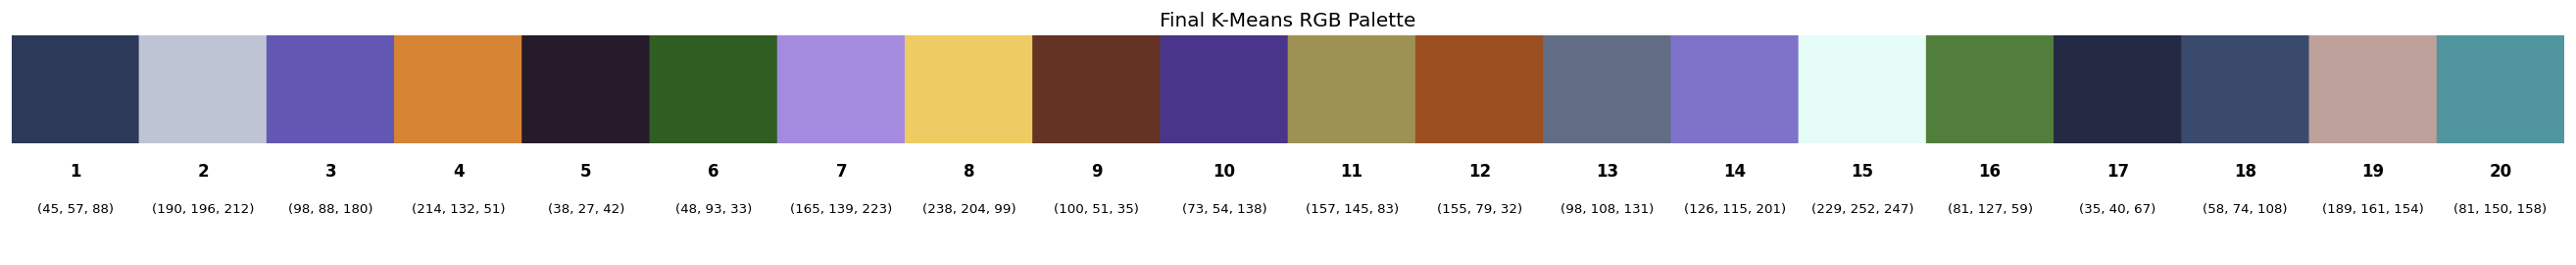

In [4]:
plot_palette(kmeans_palette, "Final K-Means RGB Palette", f"{OUTPUT_DIR}/04_final_palette.png")

## 정량 평가 표

In [5]:
metrics = region_metrics(numbered_regions, image.shape, small_area=300)
performance_rows = [
    {"stage": "Input Simplification", "runtime_sec": simplify_time, "color_error": "", "unique_colors": count_unique_colors(simplified_image), "edge_density": "", "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "K-Means", "runtime_sec": kmeans_time, "color_error": quality_rows[0]["color_error"], "unique_colors": quality_rows[0]["unique_colors"], "edge_density": "", "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Posterization", "runtime_sec": poster_time, "color_error": quality_rows[1]["color_error"], "unique_colors": quality_rows[1]["unique_colors"], "edge_density": "", "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Median Cut", "runtime_sec": median_time, "color_error": quality_rows[2]["color_error"], "unique_colors": quality_rows[2]["unique_colors"], "edge_density": "", "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Sobel", "runtime_sec": sobel_time, "color_error": "", "unique_colors": "", "edge_density": edge_density(sobel_clean), "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Laplacian", "runtime_sec": lap_time, "color_error": "", "unique_colors": "", "edge_density": edge_density(lap_clean), "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Canny", "runtime_sec": canny_time, "color_error": "", "unique_colors": "", "edge_density": edge_density(canny_clean), "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Hybrid Color Boundary", "runtime_sec": hybrid_time, "color_error": "", "unique_colors": "", "edge_density": edge_density(hybrid_compare_clean), "regions": "", "average_area": "", "small_regions": ""},
    {"stage": "Segmentation", "runtime_sec": seg_time, "color_error": "", "unique_colors": "", "edge_density": "", "regions": metrics["regions"], "average_area": metrics["average_area"], "small_regions": metrics["small_regions"]},
    {"stage": "Background-like Regions", "runtime_sec": "", "color_error": "", "unique_colors": "", "edge_density": "", "regions": sum(1 for region in regions if region.get("is_background")), "average_area": "", "small_regions": ""},
    {"stage": "Total Final", "runtime_sec": simplify_time + kmeans_time + hybrid_time + seg_time, "color_error": "", "unique_colors": "", "edge_density": edge_density(hybrid_final_clean), "regions": metrics["regions"], "average_area": metrics["average_area"], "small_regions": metrics["small_regions"]},
]

print(f"입력 이미지: {IMAGE_PATH}  (원본 색 수: {count_unique_colors(image)}, 평탄화 후 색 수: {count_unique_colors(simplified_image)})")
print(f"요청 K = {K}\n")
print("[Color Quantization Quality]")
print_table(quality_rows, columns=["algorithm", "runtime_sec", "color_error", "unique_colors"])
print("\n[Edge Detection]")
print_table(edge_rows, columns=["algorithm", "runtime_sec", "edge_density", "hci_note"])
print("\n[Final Pipeline]")
print_table(performance_rows)

입력 이미지: data/ych.jpg  (원본 색 수: 175886, 평탄화 후 색 수: 146315)
요청 K = 20

[Color Quantization Quality]
algorithm     | runtime_sec | color_error | unique_colors
--------------+-------------+-------------+--------------
K-Means       | 0.7542      | 11.1266     | 20           
Posterization | 0.6113      | 26.8957     | 20           
Median Cut    | 0.2851      | 59.1932     | 20           

[Edge Detection]
algorithm             | runtime_sec | edge_density | hci_note            
----------------------+-------------+--------------+---------------------
Sobel                 | 0.0090      | 0.1045       | 두꺼운 변화 감지, 질감 노이즈 주의
Laplacian             | 0.0026      | 0.0548       | 세부 변화 민감, 작은 노이즈 많음 
Canny                 | 0.0024      | 0.1286       | 선명도와 노이즈 균형 우수      
Hybrid Color Boundary | 0.0326      | 0.0814       | 비슷한 밝기의 색상 경계까지 분리  

[Final Pipeline]
stage                   | runtime_sec | color_error | unique_colors | edge_density | regions | average_area | small_regions
--------

## 색상 개수별 복잡도 변화

K  | runtime_sec | edge_density | regions | average_area | small_regions
---+-------------+--------------+---------+--------------+--------------
5  | 0.2306      | 0.0746       | 1       | 467358.0000  | 0            
10 | 0.3860      | 0.0851       | 2       | 230732.5000  | 1            
20 | 0.8476      | 0.1144       | 6       | 74195.8333   | 5            
50 | 1.8933      | 0.1624       | 20      | 20810.8000   | 8            


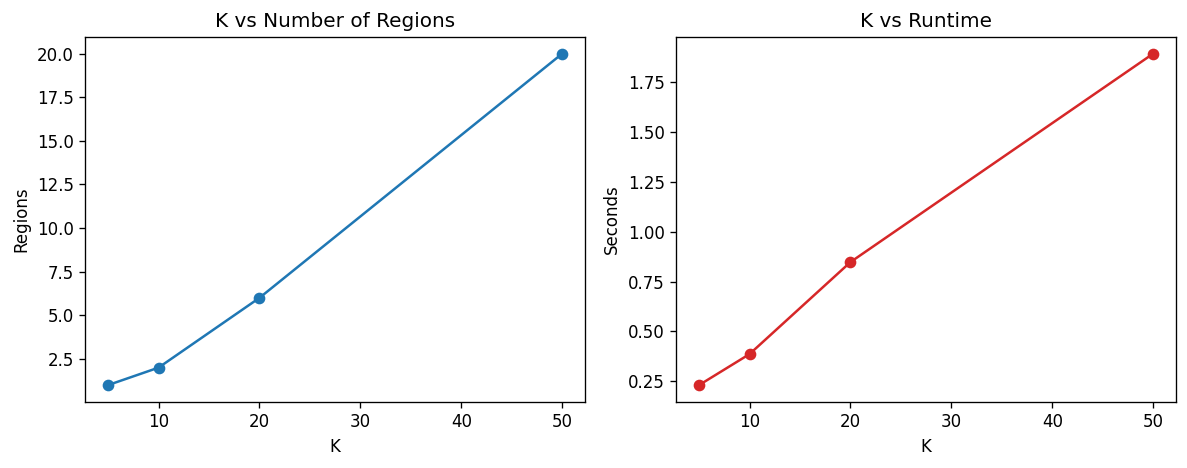

In [6]:
# K가 증가할수록 색상 표현력, 영역 수, 실행 시간이 어떻게 변하는지 측정합니다.
complexity_rows = complexity_by_k(simplified_image, k_values=K_VALUES, min_area=MIN_REGION_AREA)
print_table(complexity_rows)

ks = [row["K"] for row in complexity_rows]
regions_by_k = [row["regions"] for row in complexity_rows]
runtime_by_k = [row["runtime_sec"] for row in complexity_rows]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(ks, regions_by_k, marker="o")
axes[0].set_title("K vs Number of Regions")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Regions")
axes[1].plot(ks, runtime_by_k, marker="o", color="tab:red")
axes[1].set_title("K vs Runtime")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Seconds")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_complexity_by_k.png", dpi=160, bbox_inches="tight")
plt.show()

## 자동 정리: 알고리즘 장단점

### 색상 단순화

- K-Means 장점: 이미지 색상 분포를 반영해 대표색을 찾으므로 색상 유지 품질이 좋습니다.
- K-Means 단점: 반복 계산이 필요해 Posterization보다 느립니다.
- Posterization 장점: 매우 빠르고 구현이 단순합니다.
- Posterization 단점: 실제 이미지 색상 분포와 무관하게 균등 분할하므로 부자연스러운 색상 계단이 생길 수 있습니다.
- Median Cut 장점: 색상 분포 범위를 재귀적으로 나누므로 교육용 설명과 비교 실험에 좋습니다.
- Median Cut 단점: 고품질 최적화는 K-Means보다 약하고 구현 방식에 따라 속도 차이가 큽니다.
- 정량 비교: `color_error`는 원본과 양자화 이미지의 Lab 색 거리 평균이고 낮을수록 원본 색 보존이 좋습니다. `unique_colors`는 결과 이미지에 실제로 남은 고유색 수입니다.

### 경계선 추출

- Sobel 장점: 방향별 밝기 변화 설명이 쉽고 빠릅니다.
- Sobel 단점: 선이 두껍거나 질감 변화에 민감할 수 있습니다.
- Laplacian 장점: 모든 방향의 급격한 변화를 한 번에 감지합니다.
- Laplacian 단점: 노이즈와 작은 텍스처까지 경계로 잡는 경향이 있습니다.
- Canny 장점: 노이즈 제거와 이중 임계값을 포함해 선명하고 안정적인 경계를 제공합니다.
- Canny 단점: 밝기가 비슷한 서로 다른 색의 경계는 놓칠 수 있습니다.
- Hybrid Color Boundary 장점: Canny 결과에 색상 라벨 경계를 합쳐 겹친 색상 영역도 분리합니다.
- Hybrid Color Boundary 단점: K-Means 결과가 과분할되면 선이 많아져 복잡도가 올라갈 수 있습니다.

### 영역 분리

- Connected Components 장점: 닫힌 흰 영역을 직접 분리하고, 각 영역에 dominant 색상 번호를 넣기 쉬워 최종 산출물에 적합합니다.
- Connected Components 단점: 선이 끊기면 영역이 합쳐질 수 있어 Morphology 보정이 중요합니다.
- 배경 번호 병합 장점: 외곽에서 추정한 배경색과 비슷한 내부 빈 공간도 같은 배경 번호로 표시되어 색상표와 일관됩니다.
- Contour Detection 장점: 외곽선 시각화와 영역 형태 확인이 쉽습니다.
- Contour Detection 단점: 내부 계층 구조 처리가 필요할 수 있습니다.
- Watershed 장점: 겹친 객체 분리에 강합니다.
- Watershed 단점: 컬러링북에서는 과분할로 인해 사용자가 색칠하기 어려운 작은 영역이 늘 수 있습니다.

## 최종 알고리즘 선택 이유

최종 조합은 `K-Means + Hybrid Canny/Color Boundary + Connected Components`입니다. K-Means는 원본 색상 보존과 색상 수 제어의 균형이 좋고, Hybrid 경계선은 밝기가 비슷한 색상 사이의 경계까지 보완하며, Connected Components는 색상 번호를 넣을 색칠 영역을 직접 계산하기 좋습니다. Contour Detection과 Watershed는 최종 선택이 아니라 비교와 설명용 보조 결과로 저장합니다.

## Trade-off 분석

- K 증가: 원본과 비슷해지지만 영역 수와 번호 수가 늘어 색칠 난이도가 올라갑니다.
- 선 두께 증가: 경계 가독성은 좋아지지만 색칠 공간이 줄고 작은 영역이 사라질 수 있습니다.
- 최소 영역 크기 증가: 번호 가독성은 좋아지지만 세부 묘사가 줄어듭니다.
- Canny 임계값 증가: 노이즈는 줄지만 필요한 경계가 누락될 수 있습니다.

## 발표용 비교 포인트

- 같은 이미지에서 K=5, 10, 20, 50 결과를 비교하며 복잡도 변화를 설명합니다.
- K-Means, Posterization, Median Cut의 색상 오차와 실제 고유색 수를 비교합니다.
- Sobel, Laplacian, Canny, Hybrid의 Edge Density와 시각적 노이즈를 비교합니다.
- 영역 개수, 평균 영역 크기, 작은 영역 개수를 HCI 지표로 연결합니다.
- 최종 결과는 K-Means 색상표 번호와 영역 번호가 연결되므로, 같은 색상 영역은 같은 숫자로 칠할 수 있습니다.

## HCI 관점 개선점

- 색상 단순화로 사용자가 선택해야 할 색의 수를 줄였습니다.
- 검은 선/흰 배경 형태로 출력해 인쇄와 색칠에 적합하게 만들었습니다.
- 작은 영역 제거로 색칠 스트레스와 번호 혼잡을 줄였습니다.
- 중심 기반 번호 배치와 겹침 회피로 번호 인식 편의성을 높였습니다.
- 성능 표와 복잡도 그래프로 사용자 난이도와 알고리즘 파라미터의 관계를 설명할 수 있습니다.